In [54]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(scales)
library(stringr)

In [55]:
dataset <- read_csv("../data_preprocessed/processed_seoul_bike_sharing.csv")
head(dataset)

dataset1 <- read_csv("../data_preprocessed/processed_bike_sharing_systems.csv")
head(dataset1)

dataset2 <- read_csv("../data_preprocessed/processed_worldcities.csv")
head(dataset2)

dataset3 <- read_csv("../data_preprocessed/processed_cities_weather_forecast.csv")
head(dataset3)

Rows: 8465 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (40): RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


DATE,RENTED_BIKE_COUNT,HOUR,TEMPERATURE,HUMIDITY,WIND_SPEED,VISIBILITY,DEW_POINT_TEMPERATURE,SOLAR_RADIATION,RAINFALL,⋯,HOUR_14,HOUR_15,HOUR_16,HOUR_17,HOUR_18,HOUR_19,HOUR_20,HOUR_21,HOUR_22,HOUR_23
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0,0,⋯,0,0,0,0,0,0,0,0,0,0
01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0,0,⋯,0,0,0,0,0,0,0,0,0,0
01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0,0,⋯,0,0,0,0,0,0,0,0,0,0
01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0,0,⋯,0,0,0,0,0,0,0,0,0,0
01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0,0,⋯,0,0,0,0,0,0,0,0,0,0
01/12/2017,100,5,-6.4,37,1.5,2000,-18.7,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Rows: 480 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): COUNTRY, CITY, SYSTEM
dbl (1): BICYCLES

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


COUNTRY,CITY,SYSTEM,BICYCLES
<chr>,<chr>,<chr>,<dbl>
Albania,Tirana,NA,200
Argentina,Mendoza,NA,40
Argentina,"San Lorenzo, Santa Fe",Biciudad,80
Argentina,Buenos Aires,Serttel Brasil,4000
Argentina,Rosario,NA,480
Australia,Melbourne,PBSC & 8D,676


Rows: 26569 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): CITY, CITY_ASCII, COUNTRY, ISO2, ISO3, ADMIN_NAME, CAPITAL
dbl (4): LAT, LNG, POPULATION, ID

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


CITY,CITY_ASCII,LAT,LNG,COUNTRY,ISO2,ISO3,ADMIN_NAME,CAPITAL,POPULATION,ID
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
Tokyo,Tokyo,35.6897,139.6922,Japan,JP,JPN,Tōkyō,primary,37977000,1392685764
Jakarta,Jakarta,-6.2146,106.8451,Indonesia,ID,IDN,Jakarta,primary,34540000,1360771077
Delhi,Delhi,28.6600,77.2300,India,IN,IND,Delhi,admin,29617000,1356872604
Mumbai,Mumbai,18.9667,72.8333,India,IN,IND,Mahārāshtra,admin,23355000,1356226629
Manila,Manila,14.5958,120.9772,Philippines,PH,PHL,Manila,primary,23088000,1608618140
Shanghai,Shanghai,31.1667,121.4667,China,CN,CHN,Shanghai,admin,22120000,1156073548


Rows: 160 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): CITY, WEATHER, SEASON
dbl (9): VISIBILITY, TEMP, TEMP_MIN, TEMP_MAX, PRESSURE, HUMIDITY, WIND_SPEE...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


CITY,WEATHER,VISIBILITY,TEMP,TEMP_MIN,TEMP_MAX,PRESSURE,HUMIDITY,WIND_SPEED,WIND_DEG,FORECAST_DATETIME,SEASON
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Seoul,Clear,10000,16.09,16.09,16.74,1017,72,1.16,353,1789408800,Winter
Seoul,Clear,10000,16.05,16.05,16.19,1017,66,0.79,48,1789419600,Winter
Seoul,Clear,10000,20.32,20.32,20.32,1018,48,0.62,358,1789430400,Winter
Seoul,Clear,10000,24.99,24.99,24.99,1017,36,1.90,293,1789441200,Winter
Seoul,Clear,10000,26.92,26.92,26.92,1016,26,3.98,290,1789452000,Winter
Seoul,Clear,10000,23.86,23.86,23.86,1016,25,3.45,308,1789462800,Winter


Formating of the data, namely "%d/%m/%Y".  
Also, coercing `HOUR` levels to be an ordered sequence. This will ensure the will visualizations correctly utilize HOURS as a discrete variable with the expected ordering.  
Finally, we take a look at some high level statistics of the seoul_bike_sharing dataset.

In [56]:
dataset$DATE <- as.Date(dataset$DATE, format = "%d/%m/%Y")
dataset$HOUR <- factor(dataset$HOUR, levels = sort(unique(dataset$HOUR)), ordered = TRUE)
sum(is.na(dataset))
summary(dataset)

[1] 0

      DATE            RENTED_BIKE_COUNT      HOUR       TEMPERATURE    
 Min.   :2017-12-01   Min.   :   2.0    7      : 353   Min.   :-17.80  
 1st Qu.:2018-02-27   1st Qu.: 214.0    8      : 353   1st Qu.:  3.00  
 Median :2018-05-28   Median : 542.0    9      : 353   Median : 13.50  
 Mean   :2018-05-28   Mean   : 729.2    10     : 353   Mean   : 12.77  
 3rd Qu.:2018-08-24   3rd Qu.:1084.0    11     : 353   3rd Qu.: 22.70  
 Max.   :2018-11-30   Max.   :3556.0    12     : 353   Max.   : 39.40  
                                        (Other):6347                   
    HUMIDITY       WIND_SPEED      VISIBILITY   DEW_POINT_TEMPERATURE
 Min.   : 0.00   Min.   :0.000   Min.   :  27   Min.   :-30.600      
 1st Qu.:42.00   1st Qu.:0.900   1st Qu.: 935   1st Qu.: -5.100      
 Median :57.00   Median :1.500   Median :1690   Median :  4.700      
 Mean   :58.15   Mean   :1.726   Mean   :1434   Mean   :  3.945      
 3rd Qu.:74.00   3rd Qu.:2.300   3rd Qu.:2000   3rd Qu.: 15.200      
 Max

### Some Basic Observations:
- We can see from `DATE` that we have exactly a full year of data.  
- No records have zero bike counts.  
- Spring and Winter have the same count of records, while autumn has the least and Summer has the most.
- Temperature has a large range, so we might expect it to explain at least some of the variation in bike rentals.  
- Precipitation seems to be quite rare, only happening in the fourth quartiles for both `RAINFALL` and `SNOWFALL`.
- The average `WINDSPEED` is very light at only 1.7 m/s, and even the maximum is only a moderate breeze (Google 'Beaufort Wind Scale' to find the different wind descriptions)  

By now, you might agree that Exploratory Data Analysis can create more questions than answers. That's okay - you'll have a much deeper understanding and appreciation for your data as a result! 

Calculating how many holidays there are in the data along with their percentage.

In [57]:
filtered_df <- dataset %>% filter(HOLIDAY == "Holiday")
holiday_count <- count(filtered_df)
holiday_count

holiday_perc <- (holiday_count/nrow(dataset)) * 100
holiday_perc

n
<int>
408


n
<dbl>
4.819846


Comparing the amount of expected values vs the amount of actual values

In [58]:
hours <- length(unique(as.integer(dataset$HOUR)))
num_records <- hours * 365
num_records

filtered_df <- dataset %>% filter(FUNCTIONING_DAY == "Yes")
nrow(filtered_df)

[1] 8760

[1] 8465

Calculate some seasonally aggregated measures to help build some more context.  
That seems like a lot of snow.  
Now that I have some ideas about what sorts of questions can be answered through descriptive statistics, I start visualizing the data.

In [59]:
result <- dataset %>% group_by(SEASONS) %>% summarise(total_rainfall = sum(RAINFALL, na.rm = TRUE),
                                                      total_snowfall = sum(SNOWFALL, na.rm = TRUE))

result

SEASONS,total_rainfall,total_snowfall
<chr>,<dbl>,<dbl>
Autumn,227.9,123.0
Spring,403.8,0.0
Summer,559.7,0.0
Winter,70.9,534.6


## Data Visualization

Taking a closer look at our main variable of interest, namely, `RENTED_BIKE_COUNT`.   

Indeed, it is a measured quantity, and we expect it to depend on factors such as the expected weather.  
Evidently, if the immediate or forecasted weather is harsh or unpleasant, many people could choose to use alternate transit or simply wait for better weather rather than rent a bike.   
On the other hand, many people may be inspired to ride under pleasant expected weather conditions.  

The weather is largely infuenced by the time of day and the seasons, so these are also factors.  
The time of day, the day of week, and Holidays all matter because they control commuting schedules.  

Finer granularity data such as a unique ID for each bike and/or rider, when and where each bike was rented, or even finer - a history of when and where each bike was used or idle - would be interesting as well.

The variable of interest is a time series, so I start by taking a look at it in it's natural form?  
Also, I tune the opacity using the `alpha` parameter such that the points don't obscure each other too much.

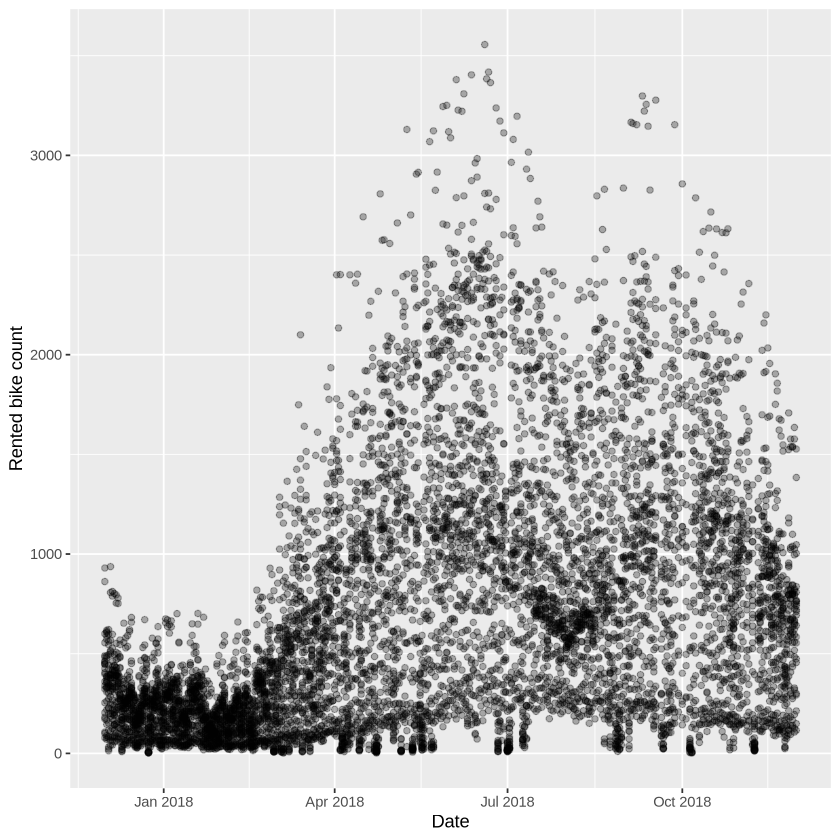

In [60]:
ggplot(dataset, aes(x = DATE, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.3) +
  labs(
    x = "Date",
    y = "Rented bike count"
  )

Bike rentals are strongly seasonal, with substantially greater demand during the warmer part of the year.

Let's see if we can enhance some of these features by incorporating colour. Given the nature of the observations so far, `HOUR` is a great candidate for this task.

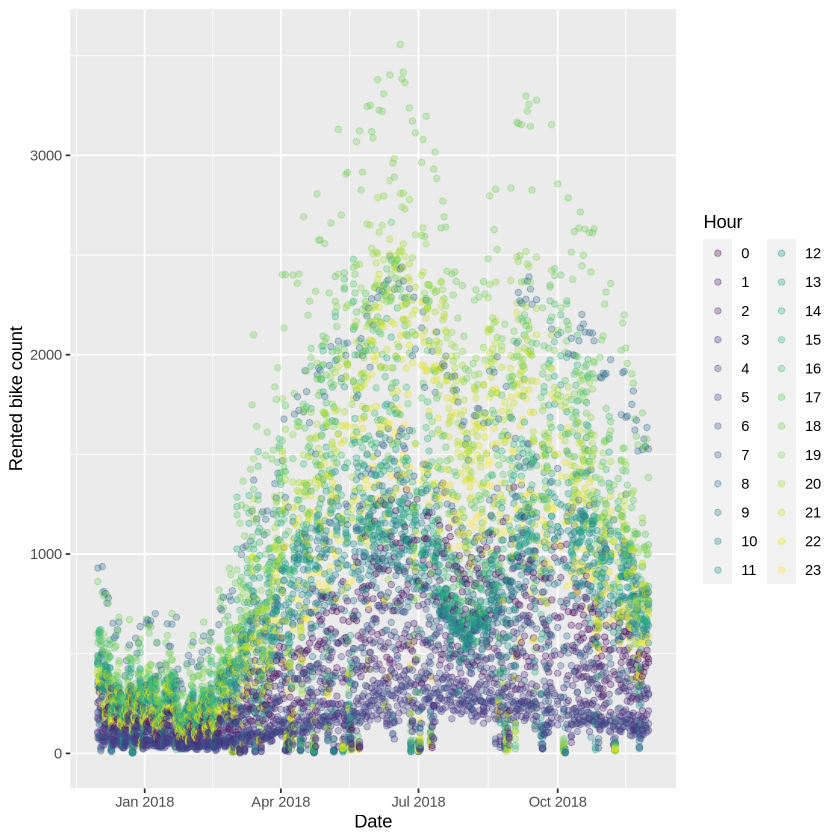

In [61]:
ggplot(dataset, aes(x = DATE, y = RENTED_BIKE_COUNT, color = HOUR)) +
  geom_point(alpha = 0.3) +
  labs(
    x = "Date",
    y = "Rented bike count",
    color = "Hour"
  )

Bike demand depends strongly on both season and hour of day with the majority being in the summer, in the afternoon.

Next, I examine the distribution of the target variable by normalizing the histogram so the y axis represents 'density'.  
This is achieved by setting `y=..density..` in the aesthetics of the histogram.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


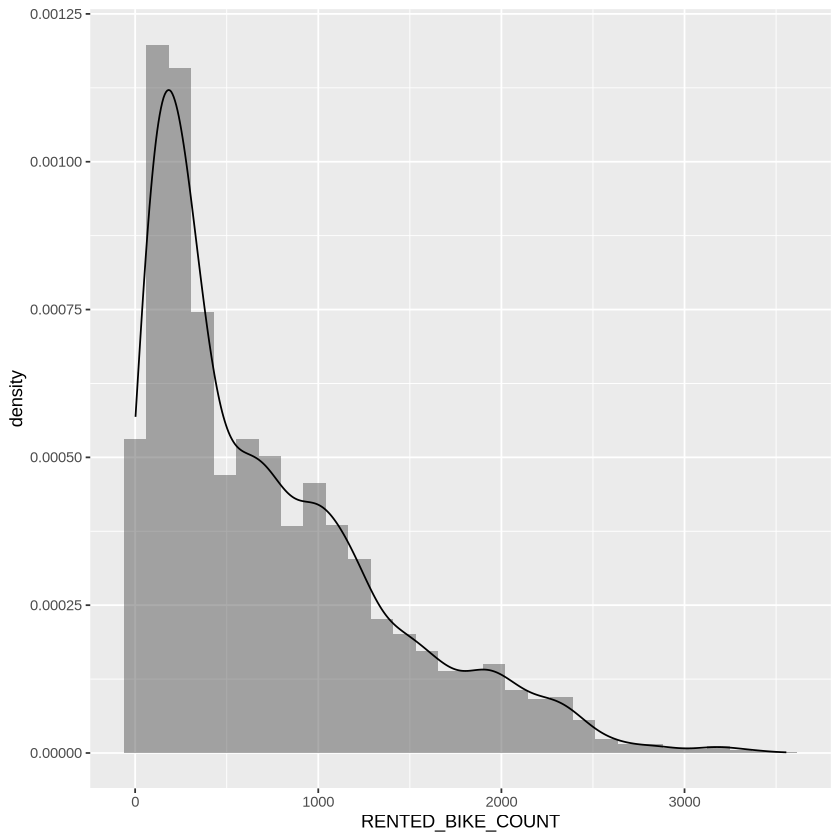

In [62]:
ggplot(dataset, aes(x = RENTED_BIKE_COUNT)) +
  geom_histogram(aes(y = after_stat(density)), alpha = 0.5) +
  geom_density()

We can see from the histogram that most of the time there are relatively few bikes rented. Indeed, the 'mode', or most frequent amount of bikes rented, is about 250.

Judging by the 'bumps' at about 700, 900, and 1900, and 3200 bikes, it looks like there may be other modes hiding within subgroups of the data.

Interestingly, judging from the tail of the distribution, on rare occasions there are many more bikes rented out than usual.

Using a scatter plot to visualize the correlation between `RENTED_BIKE_COUNT` and `TEMPERATURE` by `SEASONS`  
I start with `RENTED_BIKE_COUNT` vs. `TEMPERATURE`, then I generate four plots corresponding to the `SEASONS` by adding a facet_wrap() layer.  
Also, I make use of colour and opacity to emphasize any patterns that emerge and I used `HOUR` as the color.

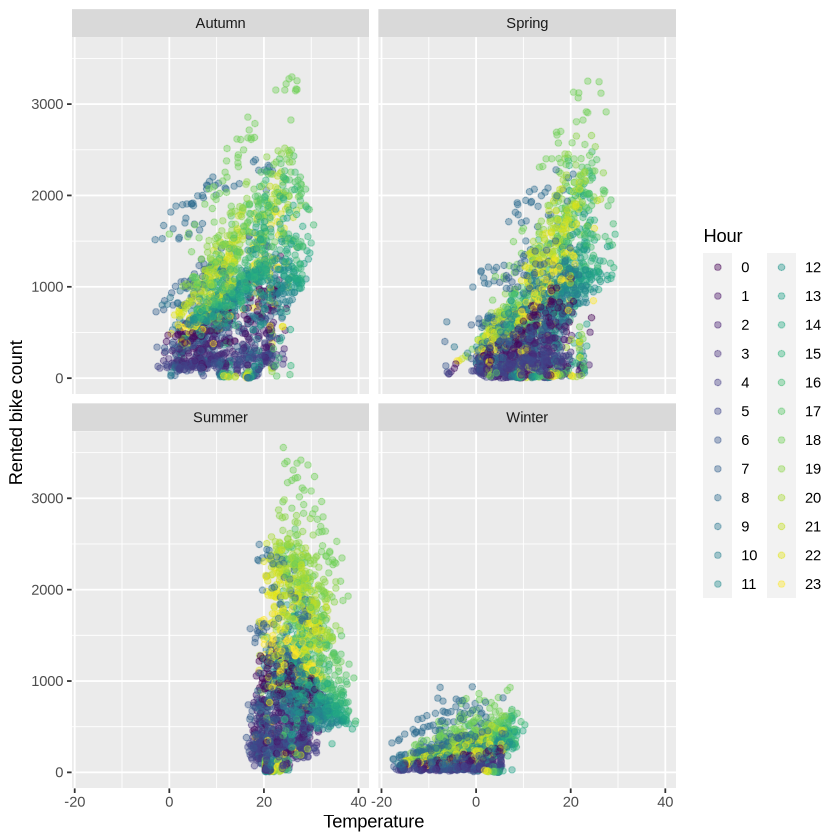

In [63]:
ggplot(dataset, aes(x = TEMPERATURE, y = RENTED_BIKE_COUNT, color = HOUR)) +
  geom_point(alpha = 0.4) +
  facet_wrap(~ SEASONS) +
  labs(
    x = "Temperature",
    y = "Rented bike count",
    color = "Hour"
  )

Visually, we can see some strong correlations as approximately linear patterns.  

Comparing this plot to the same plot below, but without grouping by `SEASONS`, shows how important seasonality is in explaining bike rental counts.

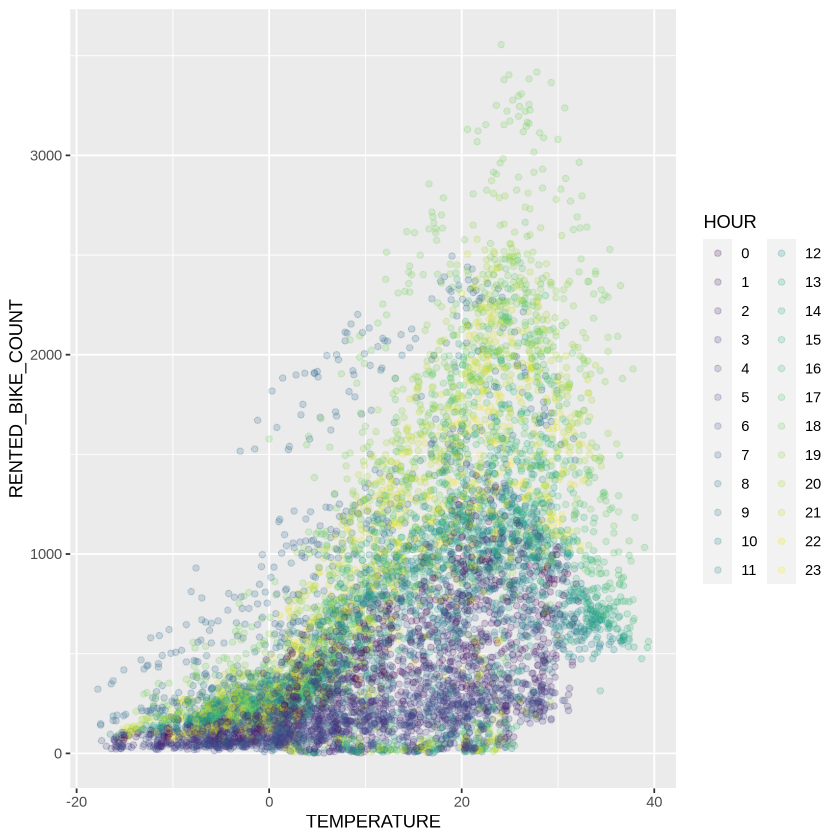

In [64]:
ggplot(dataset) +
   geom_point(aes(x=TEMPERATURE,y=RENTED_BIKE_COUNT,colour=HOUR),alpha=1/5)

Create a display of four boxplots of `RENTED_BIKE_COUNT` vs. `HOUR` grouped by `SEASONS`.  
I also used `facet_wrap` to generate four plots corresponding to the seasons.

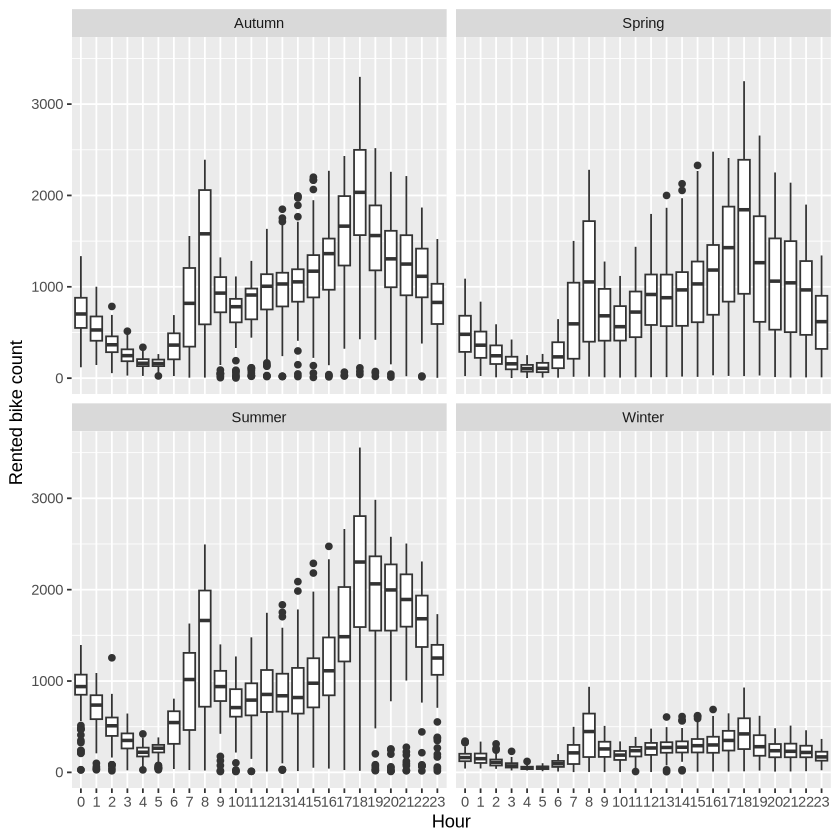

In [65]:
ggplot(dataset, aes(x = HOUR, y = RENTED_BIKE_COUNT)) +
  geom_boxplot() +
  facet_wrap(~ SEASONS) +
  labs(
    x = "Hour",
    y = "Rented bike count"
  )

Although the overall scale of bike rental counts changes with the seasons, key features remain very similar.  
For example, peak demand times are the same across all seasons, at 8 am and 6 pm.

I group the data by `DATE`, and I use the summarize() function to calculate the daily total rainfall and snowfall.  
Also, I plot the results uing a line graph to track amounts over time.

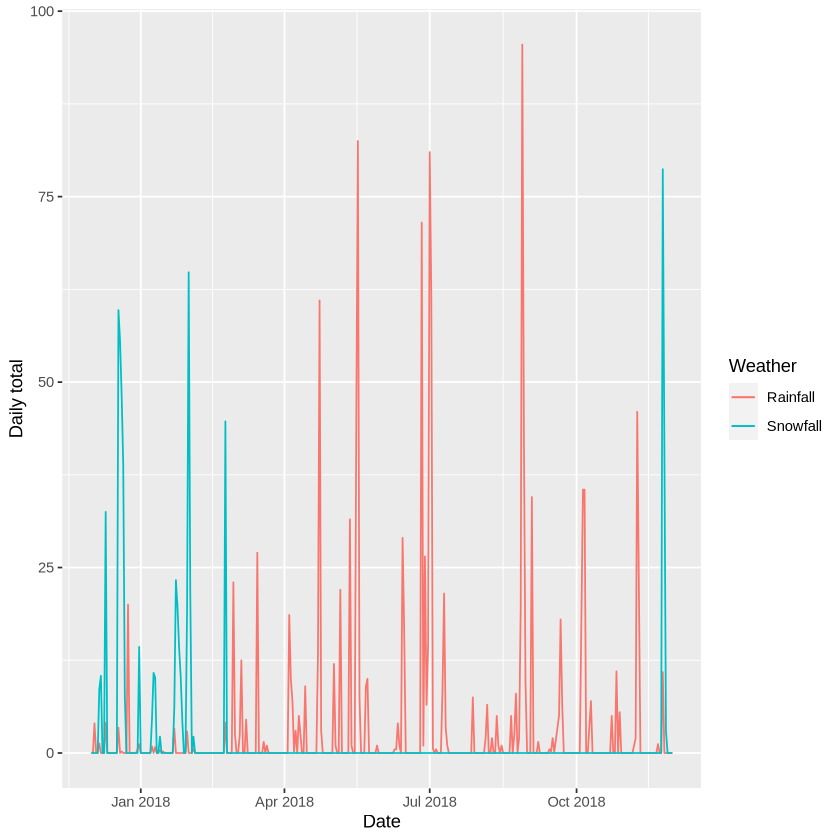

In [66]:
result <- dataset %>% group_by(DATE) %>% summarise(total_rainfall = sum(RAINFALL, na.rm = TRUE),
                                                   total_snowfall = sum(SNOWFALL, na.rm = TRUE))

ggplot(result, aes(x = DATE)) +
  geom_line(aes(y = total_rainfall, color = "Rainfall")) +
  geom_line(aes(y = total_snowfall, color = "Snowfall")) +
  labs(
    x = "Date",
    y = "Daily total",
    color = "Weather"
  )

Weather events are relatively infrequent but can produce substantial daily rainfall or snowfall, making precipitation a potentially important factor to consider when explaining unusually low bike-rental days.

This shows how the number of rented bikes changes throughout the year.  
Instead of plotting every observation, this summarizes the typical rental activity for each hour.

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


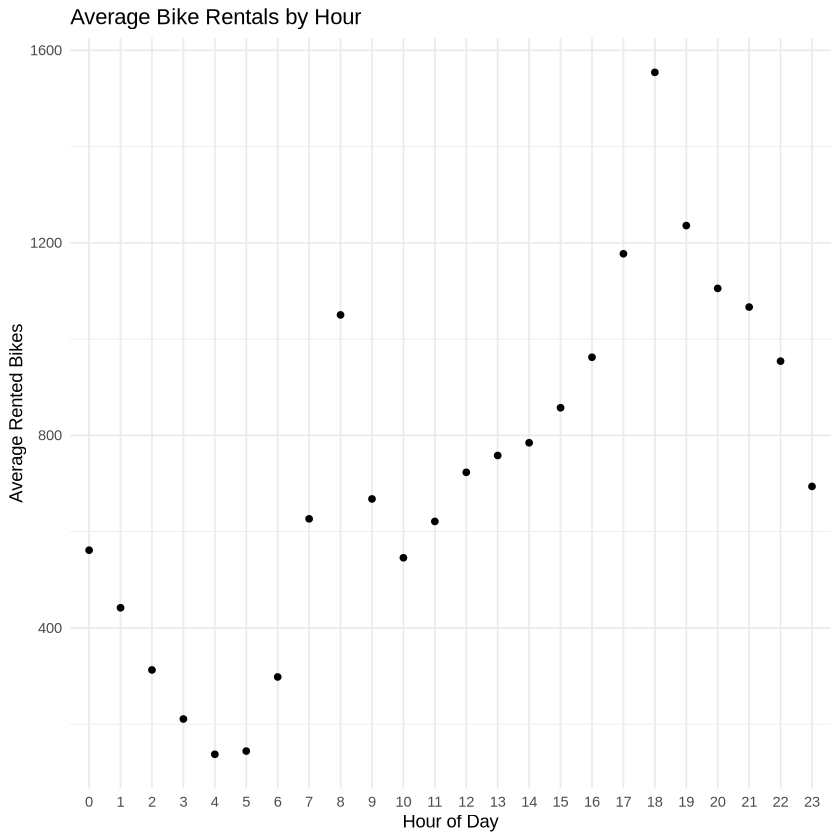

In [67]:
hourly_rentals <- dataset %>%
  group_by(HOUR) %>%
  summarise(
    average_rentals = mean(RENTED_BIKE_COUNT, na.rm = TRUE)
  )

ggplot(hourly_rentals,
       aes(x = HOUR, y = average_rentals)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Bike Rentals by Hour",
    x = "Hour of Day",
    y = "Average Rented Bikes"
  ) +
  theme_minimal()

This shows spike of activity in the morning and in the afternoon.  
Also shows dips of inactivity late in the evening and around midnight.

The code below compares the distribution of bike rentals across the different seasons.

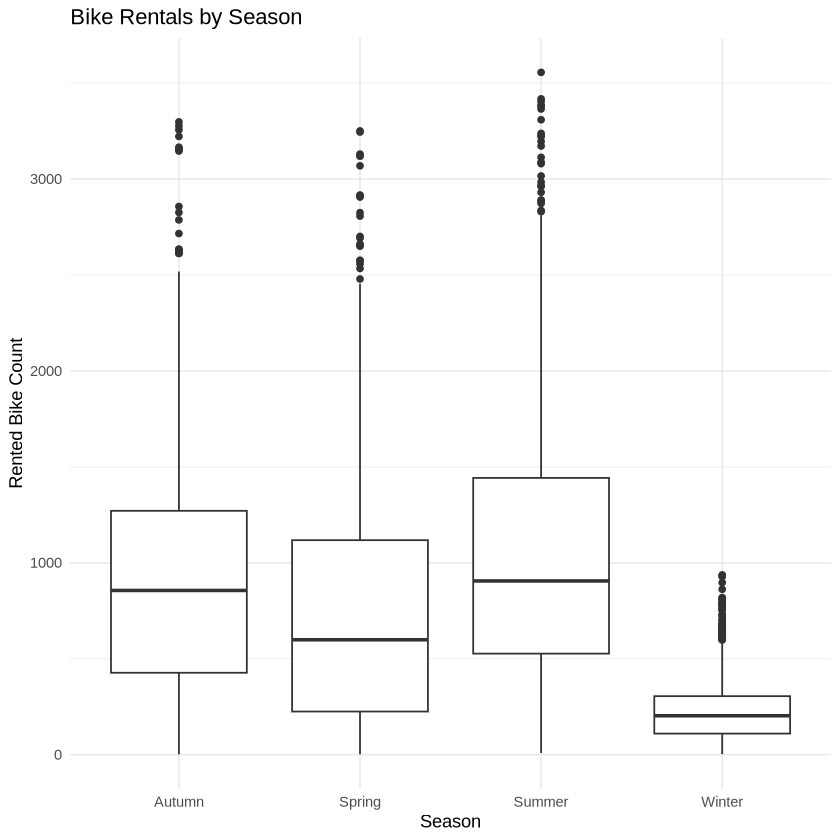

In [68]:
ggplot(dataset,
       aes(x = SEASONS, y = RENTED_BIKE_COUNT)) +
  geom_boxplot() +
  labs(
    title = "Bike Rentals by Season",
    x = "Season",
    y = "Rented Bike Count"
  ) +
  theme_minimal()

Lots of outliers and positioning of IQR indicates heavy skew to the right.

The code below allows you to compare rental behaviour on holidays and normal days.

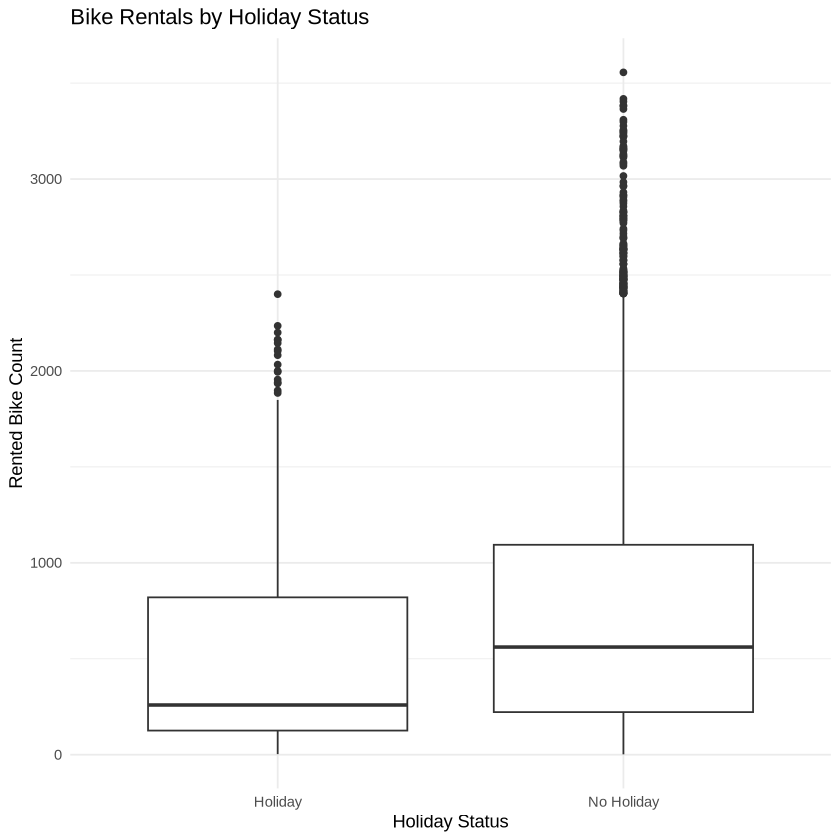

In [69]:
ggplot(dataset,
       aes(x = HOLIDAY, y = RENTED_BIKE_COUNT)) +
  geom_boxplot() +
  labs(
    title = "Bike Rentals by Holiday Status",
    x = "Holiday Status",
    y = "Rented Bike Count"
  ) +
  theme_minimal()

No holiday distribution has more spread compared to holiday and also more sever outliers.  
Both distributions indicate severe skewness to the right.

A scatter plot can show whether temperature and bike rental activity appear to be related.

`geom_smooth()` using formula = 'y ~ x'


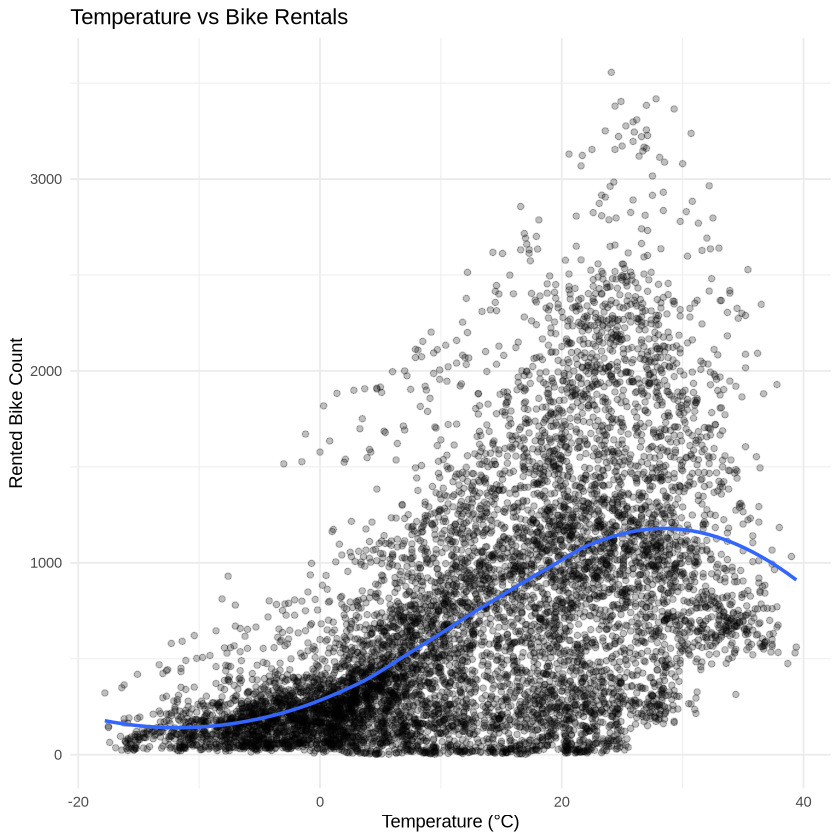

In [70]:
ggplot(dataset,
       aes(x = TEMPERATURE, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.25) +
  geom_smooth(method = "loess", se = FALSE) +
  labs(
    title = "Temperature vs Bike Rentals",
    x = "Temperature (°C)",
    y = "Rented Bike Count"
  ) +
  theme_minimal()

This indicates a positive correlation between temperature and rented bike count as the number of rented bikes increases with an increase in temperature.  
Interestingly the trends also tends to reverse with extreme temperatures like close to 40 degrees for example. INdicating a goldylocks zone between 20 and 30 degrees.

The code below examines whether rental activity changes at different humidity levels.

`geom_smooth()` using formula = 'y ~ x'


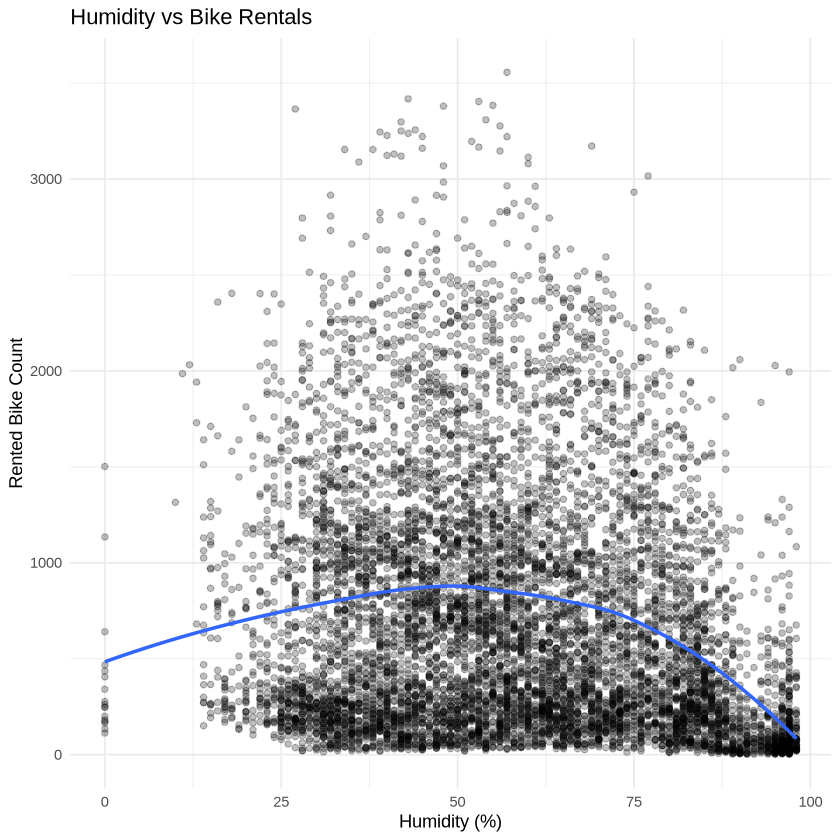

In [71]:
ggplot(dataset,
       aes(x = HUMIDITY, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.25) +
  geom_smooth(method = "loess", se = FALSE) +
  labs(
    title = "Humidity vs Bike Rentals",
    x = "Humidity (%)",
    y = "Rented Bike Count"
  ) +
  theme_minimal()

Similar pattern for humidity levels. With the goldylocks zone being at around 50 humidity.

The code below examines the relationship between wind speed and bike rentals.

`geom_smooth()` using formula = 'y ~ x'


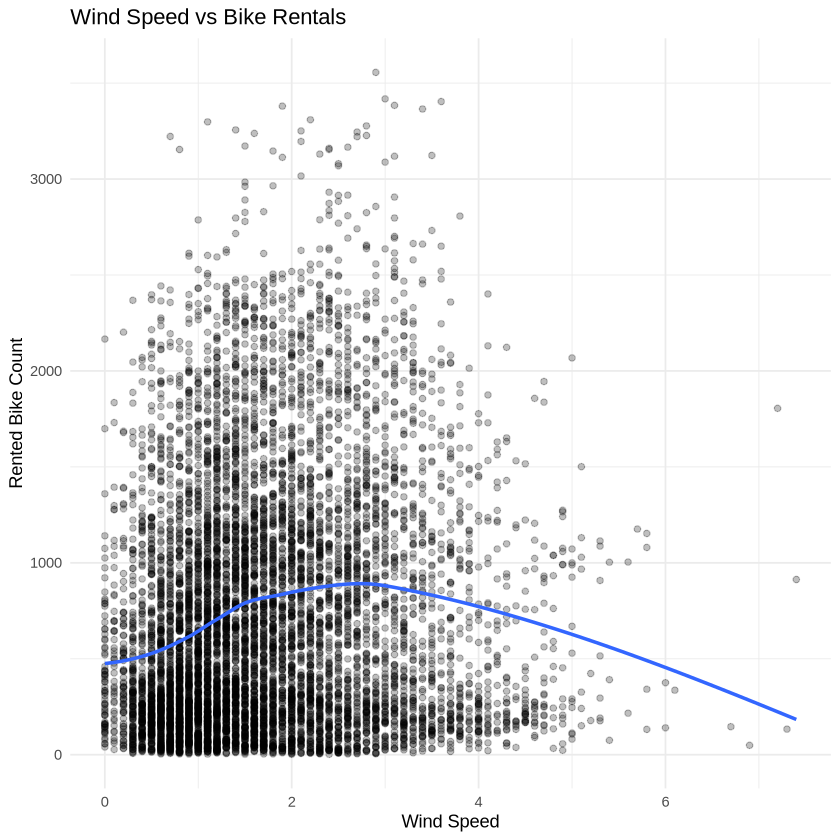

In [72]:
ggplot(dataset,
       aes(x = WIND_SPEED, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.25) +
  geom_smooth(method = "loess", se = FALSE) +
  labs(
    title = "Wind Speed vs Bike Rentals",
    x = "Wind Speed",
    y = "Rented Bike Count"
  ) +
  theme_minimal()

Similar pattern as before with the goldylocks zone being at around 3 wind speed.

Rainfall is particularly useful because it may be associated with changes in cycling behaviour.

`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -0.175”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.030625”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.175”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.175”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“zero-width neighborhood. make span bigger”
Warning message:
“Computation failed in `stat_smooth()`
Caused by error in `predLoess()`:
! NA/NaN/Inf in

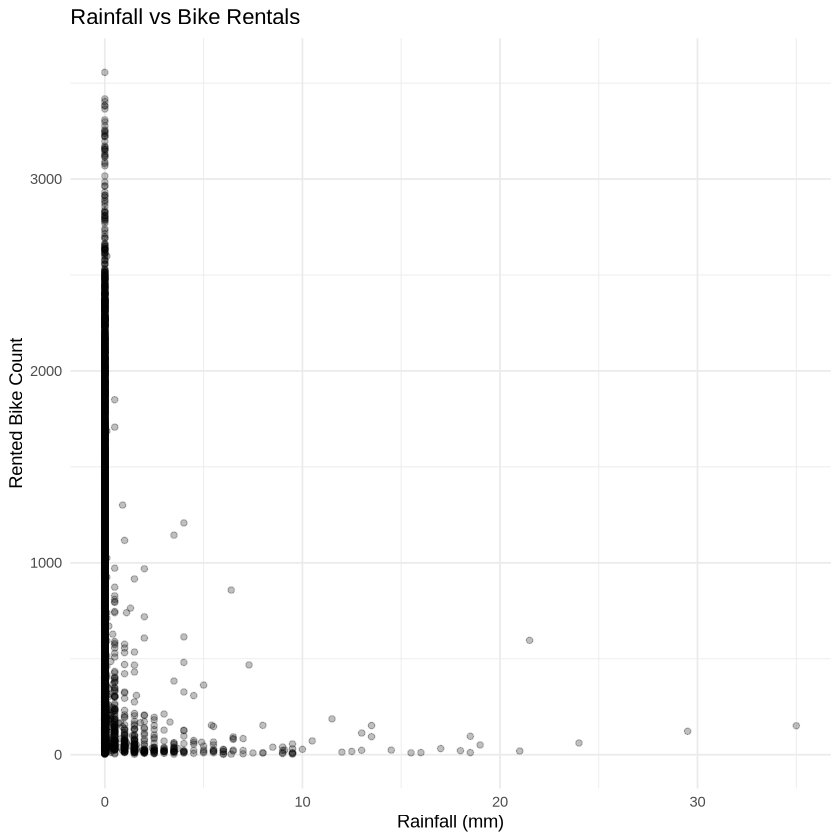

In [73]:
ggplot(dataset,
       aes(x = RAINFALL, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.25) +
  geom_smooth(method = "loess", se = FALSE) +
  labs(
    title = "Rainfall vs Bike Rentals",
    x = "Rainfall (mm)",
    y = "Rented Bike Count"
  ) +
  theme_minimal()

Pretty much the majority of bike rides occur with no rain, with a few outliers happening during rain.  
This indicated the distribution is severly skewed to the right.

Snowfall is another useful weather relationship.

`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -0.044”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.001936”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.044”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.044”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“zero-width neighborhood. make span bigger”
Warning message:
“Computation failed in `stat_smooth()`
Caused by error in `predLoess()`:
! NA/NaN/Inf in

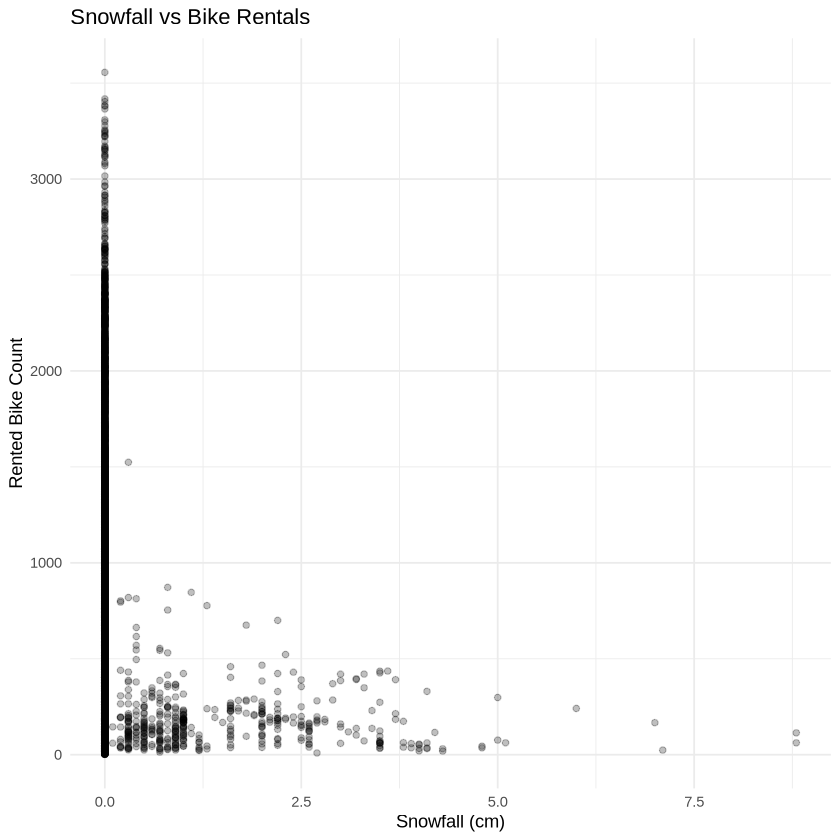

In [74]:
ggplot(dataset,
       aes(x = SNOWFALL, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.25) +
  geom_smooth(method = "loess", se = FALSE) +
  labs(
    title = "Snowfall vs Bike Rentals",
    x = "Snowfall (cm)",
    y = "Rented Bike Count"
  ) +
  theme_minimal()

Similar pattern to rainfall. But notably there are more outliers with this weather condition.  
It looks like people prefer to ride bikes in snow rather than rain.

This gives me a top-15 city comparison rather than trying to display hundreds of cities at once.

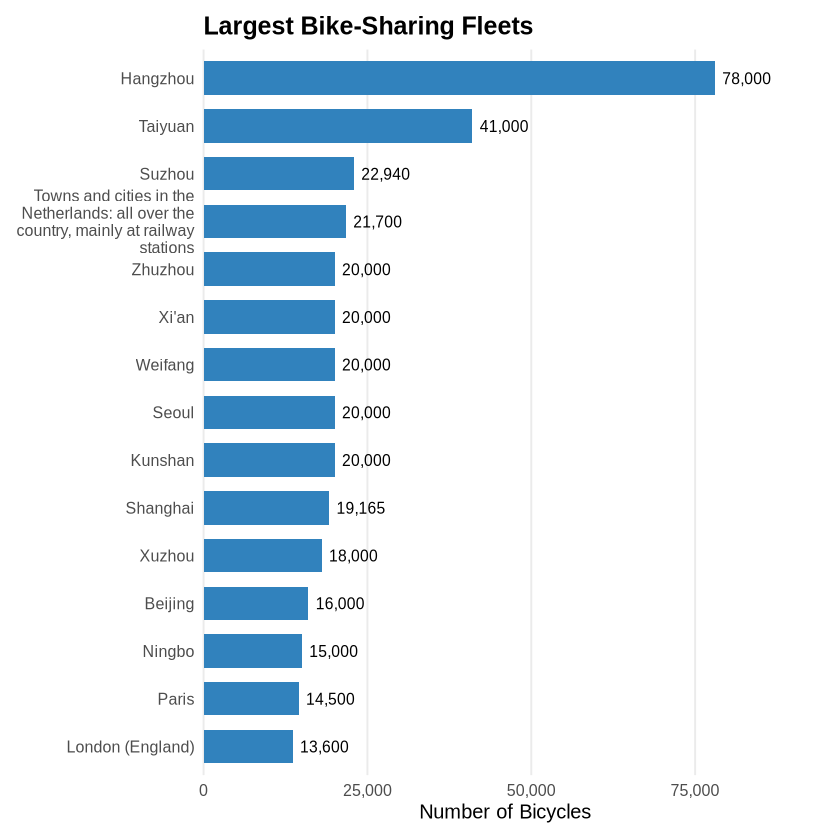

In [75]:
fleet_by_city <- dataset1 %>%
  filter(!is.na(BICYCLES)) %>%
  arrange(desc(BICYCLES)) %>%
  slice_head(n = 15)

ggplot(fleet_by_city, aes(x = reorder(CITY, BICYCLES), y = BICYCLES)) +
  geom_col(fill = "#3182bd", width = 0.7) +
  geom_text(aes(label = comma(BICYCLES)), hjust = -0.15, size = 3.3) +
  coord_flip(clip = "off") +
  scale_x_discrete(labels = function(x) str_wrap(x, width = 28)) +
  scale_y_continuous(
    labels = comma,
    expand = expansion(mult = c(0, 0.18))
  ) +
  labs(
    title = "Largest Bike-Sharing Fleets",
    x = NULL,
    y = "Number of Bicycles"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_blank(),
    plot.title = element_text(face = "bold", size = 15),
    axis.text.y = element_text(lineheight = 0.9),
    plot.margin = margin(10, 20, 10, 10)
  )

It appears bike riding is enjoyed more in ASIA.

I also aggregate the bike-sharing systems by country.

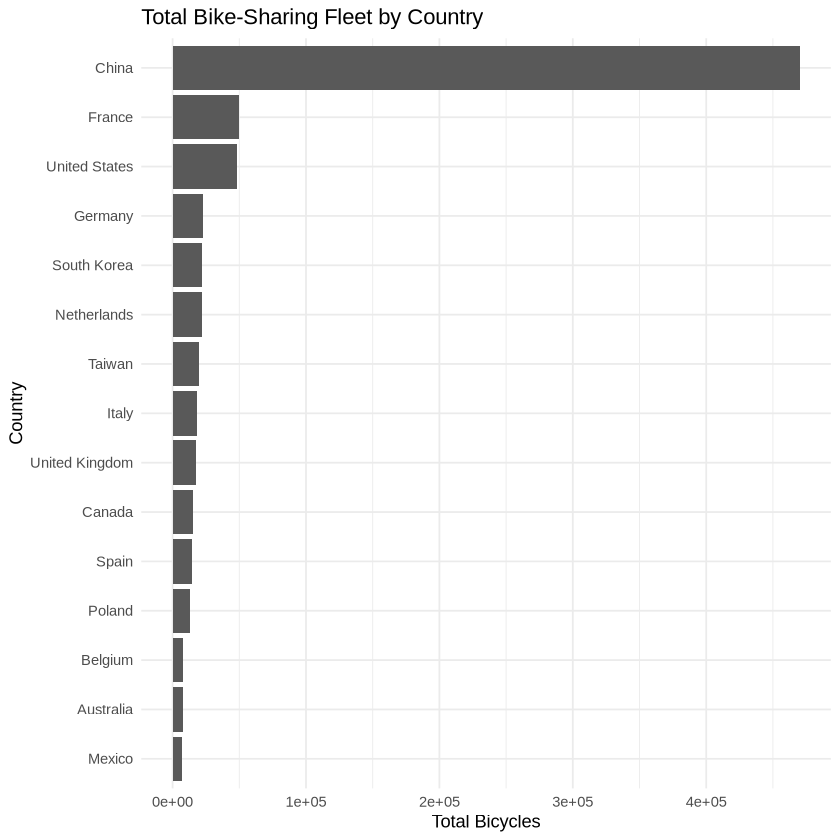

In [76]:
fleet_by_country <- dataset1 %>%
  group_by(COUNTRY) %>%
  summarise(
    total_bicycles = sum(BICYCLES, na.rm = TRUE)
  ) %>%
  arrange(desc(total_bicycles)) %>%
  slice_head(n = 15)

ggplot(fleet_by_country,
       aes(x = reorder(COUNTRY, total_bicycles),
           y = total_bicycles)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Total Bike-Sharing Fleet by Country",
    x = "Country",
    y = "Total Bicycles"
  ) +
  theme_minimal()

Overwhelming advantage in bike fleet numbers for China.

In my opinion the graph below is one of the most useful cross-dataset visualizations.  
It asks "Do cities with larger populations also tend to have larger bike-sharing fleets?" 

Warning message in inner_join(., dataset2 %>% select(CITY, COUNTRY, POPULATION), :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 39 of `x` matches multiple rows in `y`.
ℹ Row 142 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
`geom_smooth()` using formula = 'y ~ x'


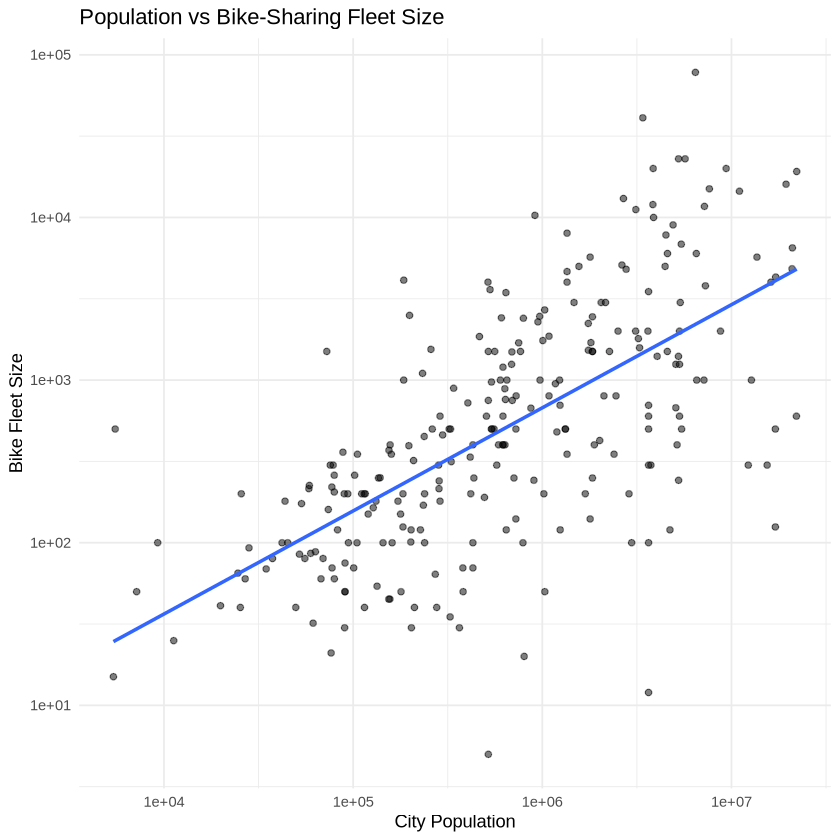

In [77]:
population_fleet <- dataset1 %>%
  inner_join(
    dataset2 %>%
      select(CITY, COUNTRY, POPULATION),
    by = c("CITY", "COUNTRY")
  ) %>%
  filter(
    !is.na(BICYCLES),
    !is.na(POPULATION),
    POPULATION > 0
  )

ggplot(population_fleet,
       aes(x = POPULATION, y = BICYCLES)) +
  geom_point(alpha = 0.5) +
  scale_x_log10() +
  scale_y_log10() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Population vs Bike-Sharing Fleet Size",
    x = "City Population",
    y = "Bike Fleet Size"
  ) +
  theme_minimal()

The log scales are useful here because both population and fleet size have very large ranges.  
The plot also indicates a positive correlation between population and bike fleet size.

Bicycles per 1,000 people.  
This normalizes fleet size by population.

Warning message in inner_join(., dataset2 %>% select(CITY, COUNTRY, POPULATION), :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 39 of `x` matches multiple rows in `y`.
ℹ Row 142 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


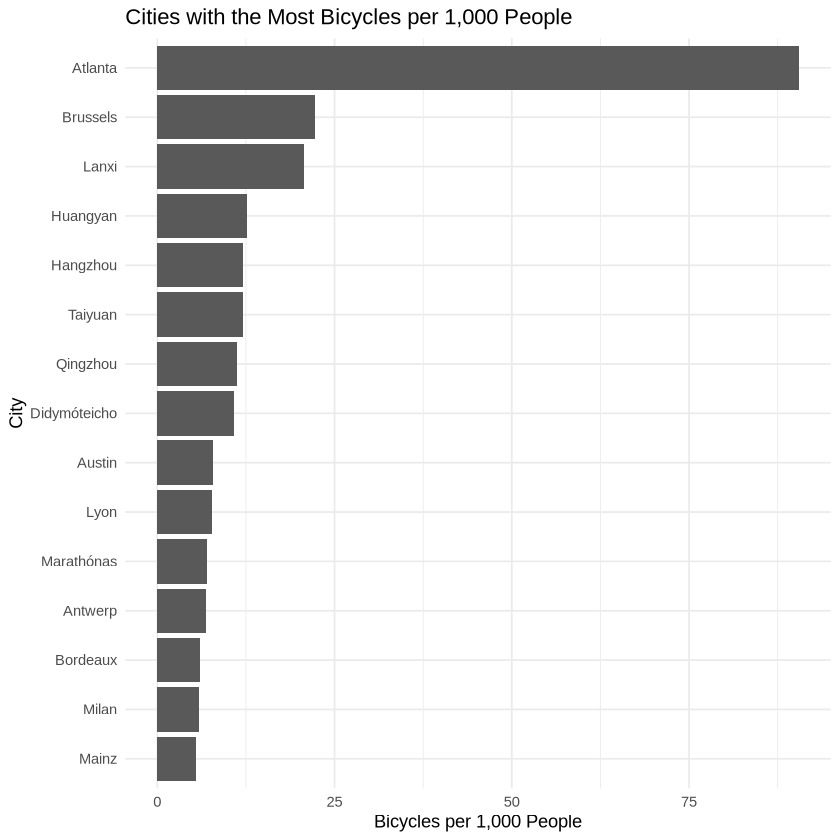

In [78]:
bike_population <- dataset1 %>%
  inner_join(
    dataset2 %>%
      select(CITY, COUNTRY, POPULATION),
    by = c("CITY", "COUNTRY")
  ) %>%
  filter(
    !is.na(BICYCLES),
    !is.na(POPULATION),
    POPULATION > 0
  ) %>%
  mutate(
    bicycles_per_1000 =
      BICYCLES * 1000 / POPULATION
  ) %>%
  arrange(desc(bicycles_per_1000)) %>%
  slice_head(n = 15)

ggplot(bike_population,
       aes(
         x = reorder(CITY, bicycles_per_1000),
         y = bicycles_per_1000
       )) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Cities with the Most Bicycles per 1,000 People",
    x = "City",
    y = "Bicycles per 1,000 People"
  ) +
  theme_minimal()

This is different from simply looking at the largest fleets because it accounts for population size.

This viualization extends the population/fleet scatter plot from earlier.

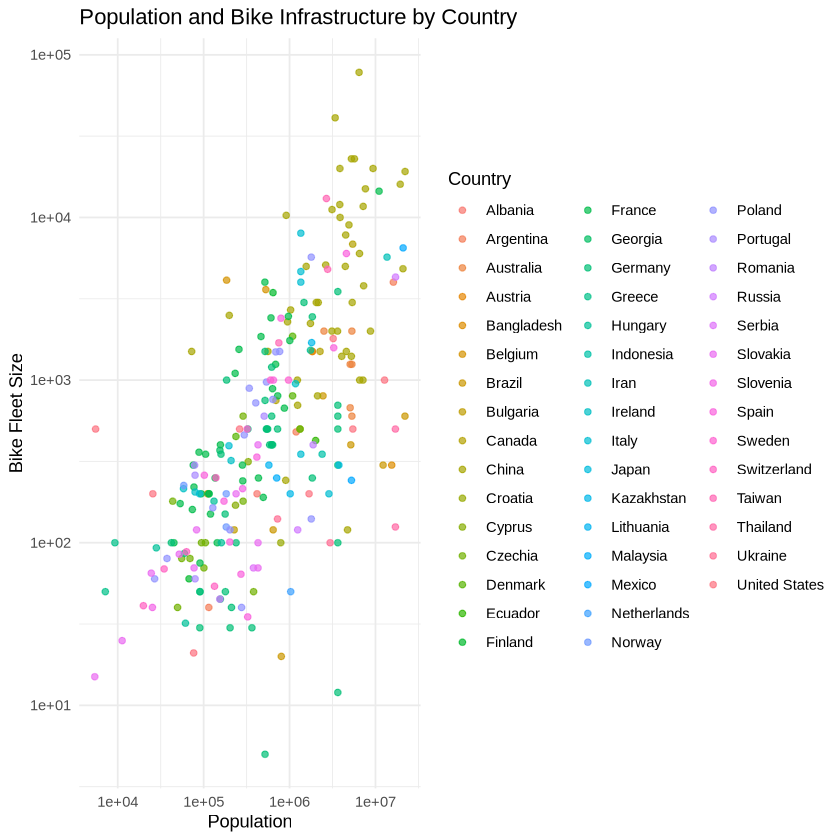

In [79]:
ggplot(population_fleet,
       aes(
         x = POPULATION,
         y = BICYCLES,
         colour = COUNTRY
       )) +
  geom_point(alpha = 0.7) +
  scale_x_log10() +
  scale_y_log10() +
  labs(
    title = "Population and Bike Infrastructure by Country",
    x = "Population",
    y = "Bike Fleet Size",
    colour = "Country"
  ) +
  theme_minimal()

Since this dataset contains LAT and LNG, you can visualize the geographic distribution of the cities.

A simple longitude/latitude scatter plot works without requiring a mapping package.

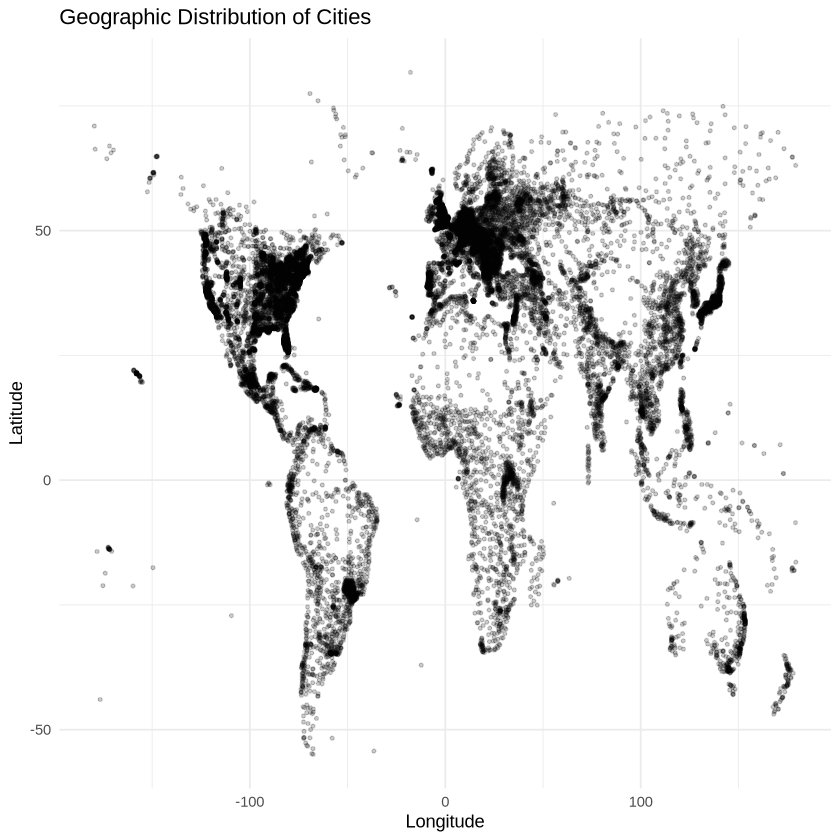

In [80]:
ggplot(dataset2,
       aes(x = LNG, y = LAT)) +
  geom_point(alpha = 0.2, size = 0.8) +
  labs(
    title = "Geographic Distribution of Cities",
    x = "Longitude",
    y = "Latitude"
  ) +
  theme_minimal()

The weather forecast dataset can be explored independently by looking at the different weather conditions.

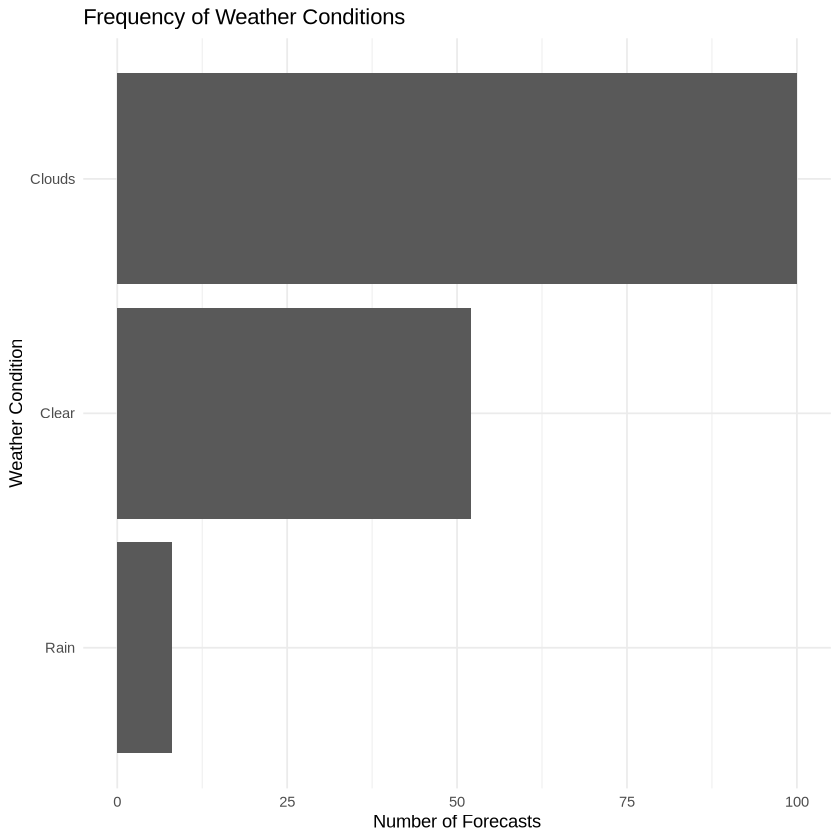

In [81]:
weather_counts <- dataset3 %>%
  count(WEATHER, sort = TRUE)

ggplot(weather_counts,
       aes(x = reorder(WEATHER, n), y = n)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Frequency of Weather Conditions",
    x = "Weather Condition",
    y = "Number of Forecasts"
  ) +
  theme_minimal()

Its mostly cludly or clear with very little rain. 

Temperature distribution across forecast cities.

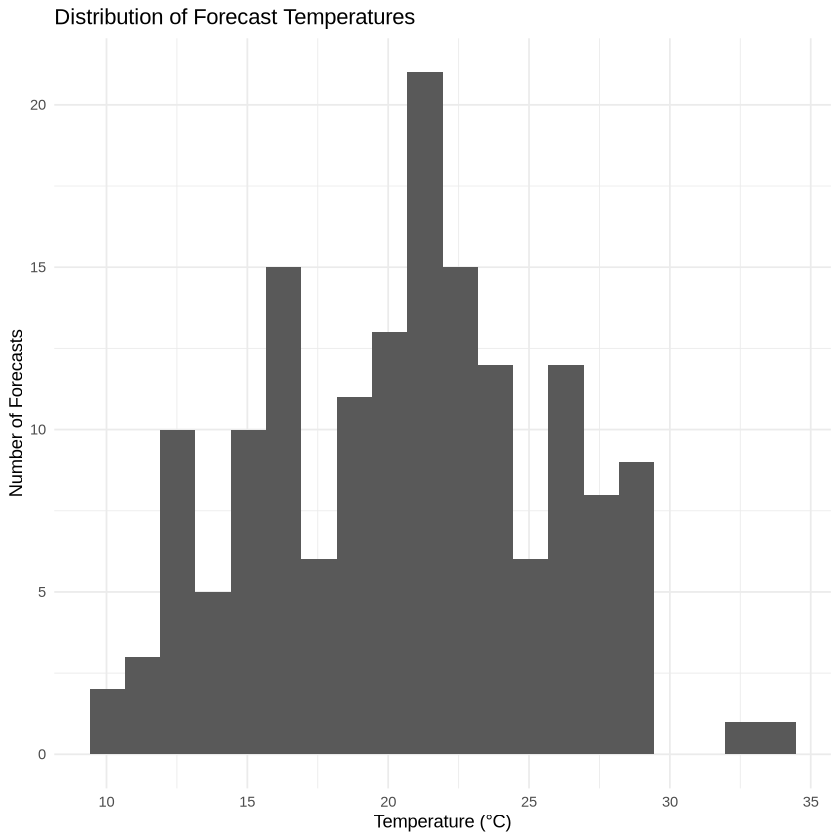

In [82]:
ggplot(dataset3,
       aes(x = TEMP)) +
  geom_histogram(bins = 20) +
  labs(
    title = "Distribution of Forecast Temperatures",
    x = "Temperature (°C)",
    y = "Number of Forecasts"
  ) +
  theme_minimal()

Distiribution looks close to a normal distribution but is slightly skewed to the right.

Forecast temperature by city.

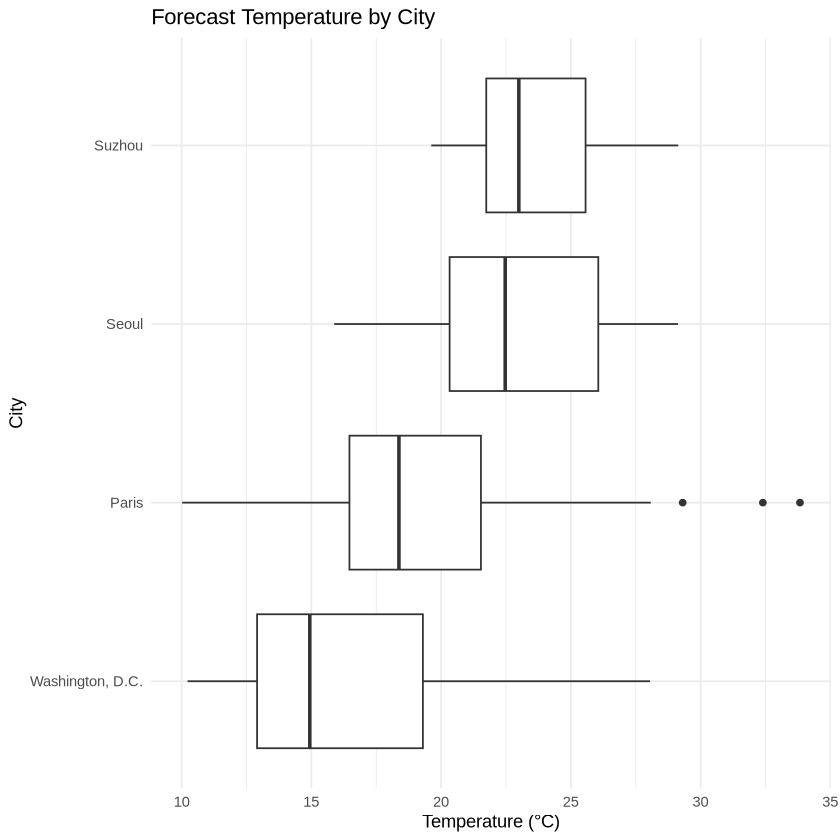

In [83]:
ggplot(dataset3,
       aes(
         x = reorder(CITY, TEMP, FUN = median),
         y = TEMP
       )) +
  geom_boxplot() +
  coord_flip() +
  labs(
    title = "Forecast Temperature by City",
    x = "City",
    y = "Temperature (°C)"
  ) +
  theme_minimal()

Very few outliers. Some of the distribution are skewed to the left while others are skewed to the right.

Bike fleet size vs forecast temperature.  
This visualization combines the bike infrastructure and weather forecast datasets.

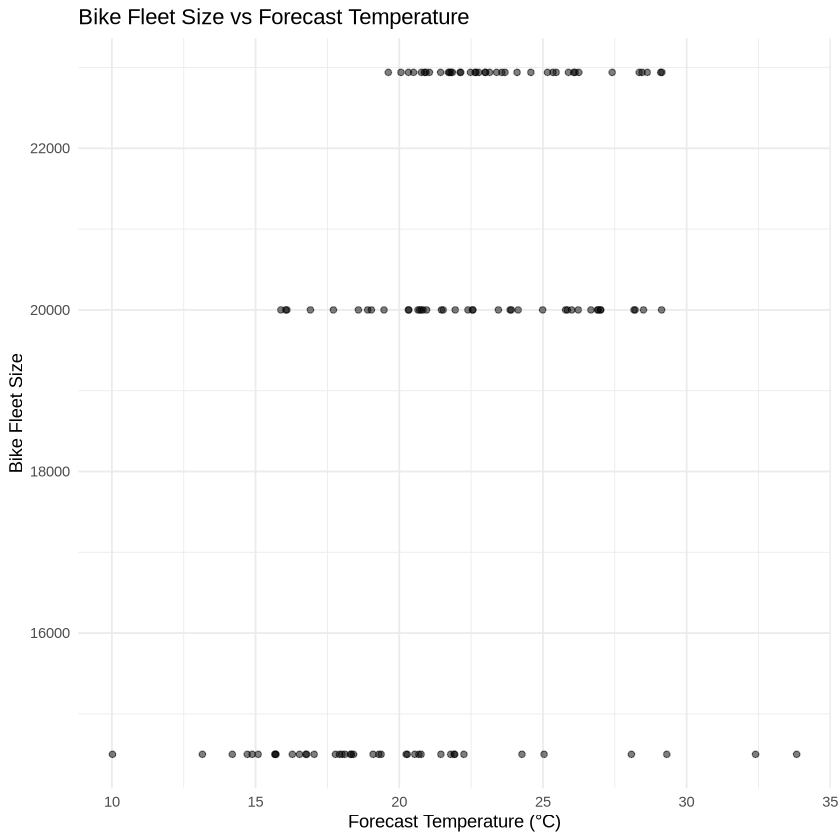

In [84]:
bike_weather <- dataset1 %>%
  inner_join(
    dataset3,
    by = "CITY"
  ) %>%
  filter(!is.na(BICYCLES))

ggplot(bike_weather,
       aes(x = TEMP, y = BICYCLES)) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Bike Fleet Size vs Forecast Temperature",
    x = "Forecast Temperature (°C)",
    y = "Bike Fleet Size"
  ) +
  theme_minimal()

Bike fleet size vs forecast humidity.

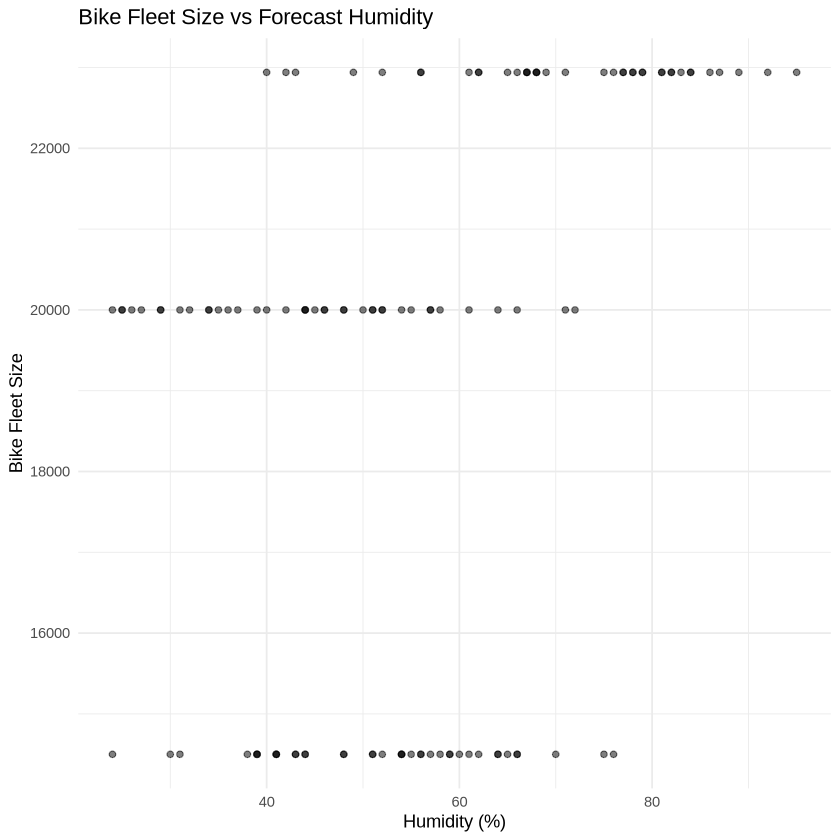

In [85]:
ggplot(bike_weather,
       aes(x = HUMIDITY, y = BICYCLES)) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Bike Fleet Size vs Forecast Humidity",
    x = "Humidity (%)",
    y = "Bike Fleet Size"
  ) +
  theme_minimal()

Bike fleet size vs forecast wind speed.

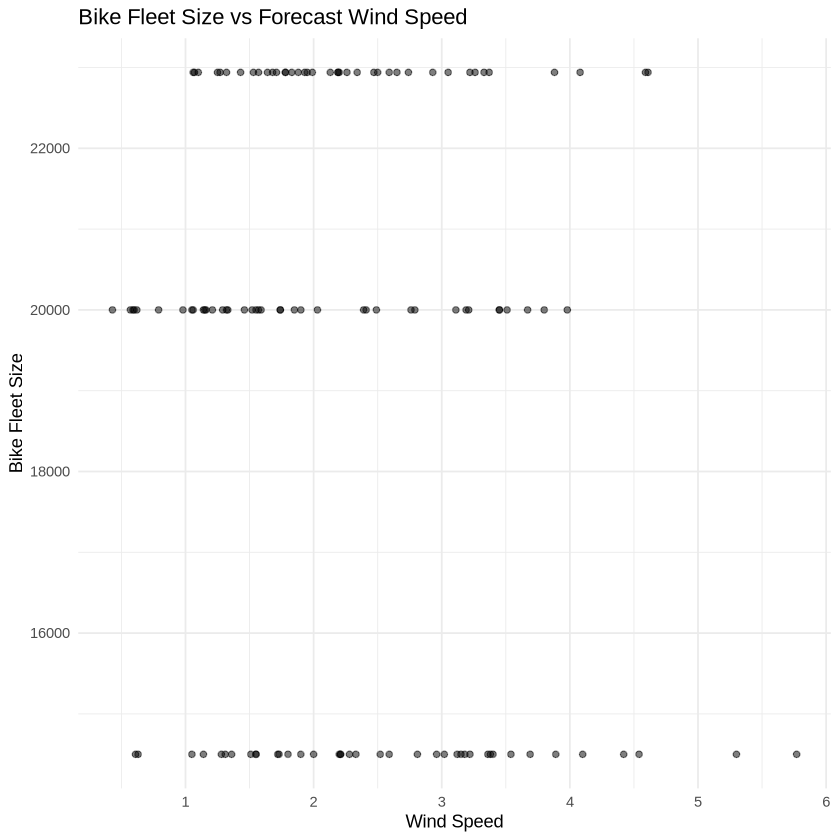

In [86]:
ggplot(bike_weather,
       aes(x = WIND_SPEED, y = BICYCLES)) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Bike Fleet Size vs Forecast Wind Speed",
    x = "Wind Speed",
    y = "Bike Fleet Size"
  ) +
  theme_minimal()

Population, bike fleet and weather together.

This is the main three-dataset visualization.

Warning message in inner_join(., dataset2 %>% select(CITY, COUNTRY, POPULATION), :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 39 of `x` matches multiple rows in `y`.
ℹ Row 142 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in inner_join(., dataset3 %>% select(CITY, TEMP, HUMIDITY, WIND_SPEED), :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 64 of `x` matches multiple rows in `y`.
ℹ Row 121 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


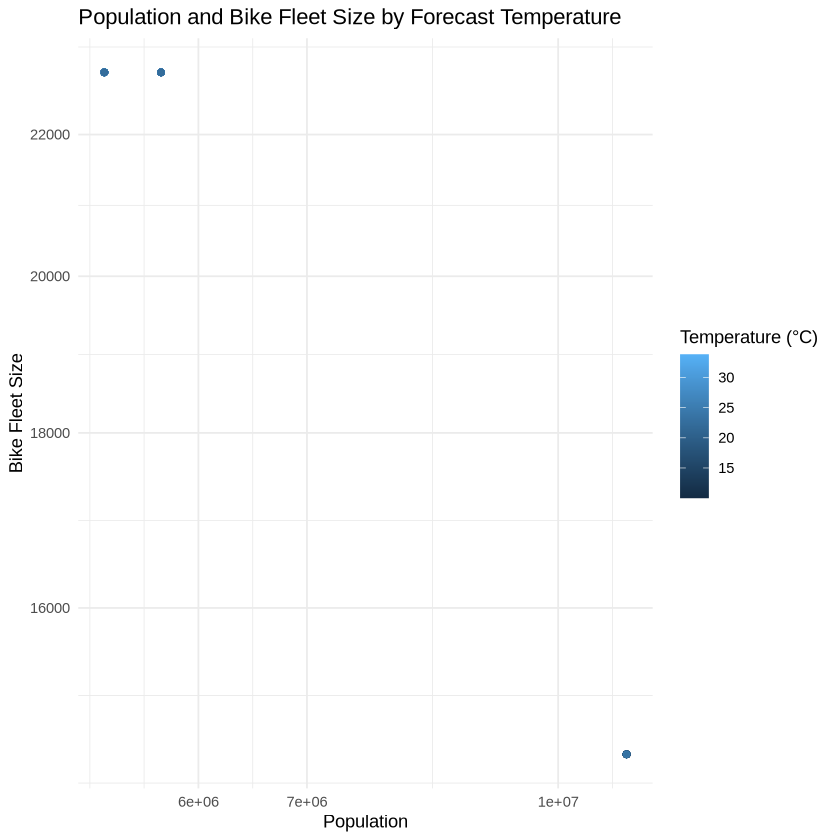

In [87]:
bike_population_weather <- dataset1 %>%
  inner_join(
    dataset2 %>%
      select(CITY, COUNTRY, POPULATION),
    by = c("CITY", "COUNTRY")
  ) %>%
  inner_join(
    dataset3 %>%
      select(CITY, TEMP, HUMIDITY, WIND_SPEED),
    by = "CITY"
  ) %>%
  filter(
    !is.na(BICYCLES),
    !is.na(POPULATION),
    POPULATION > 0
  )

  ggplot(
  bike_population_weather,
  aes(
    x = POPULATION,
    y = BICYCLES,
    colour = TEMP
  )
) +
  geom_point(alpha = 0.7) +
  scale_x_log10() +
  scale_y_log10() +
  labs(
    title = "Population and Bike Fleet Size by Forecast Temperature",
    x = "Population",
    y = "Bike Fleet Size",
    colour = "Temperature (°C)"
  ) +
  theme_minimal()

This is particularly useful because:

- X-axis: population from worldcities
- Y-axis: bike fleet from bike_sharing_systems
- Colour: forecast temperature from cities_weather_forecast

So this visualization genuinely combines three datasets.

Three datasets with weather represented by point size.

I can also use humidity as an additional dimension.

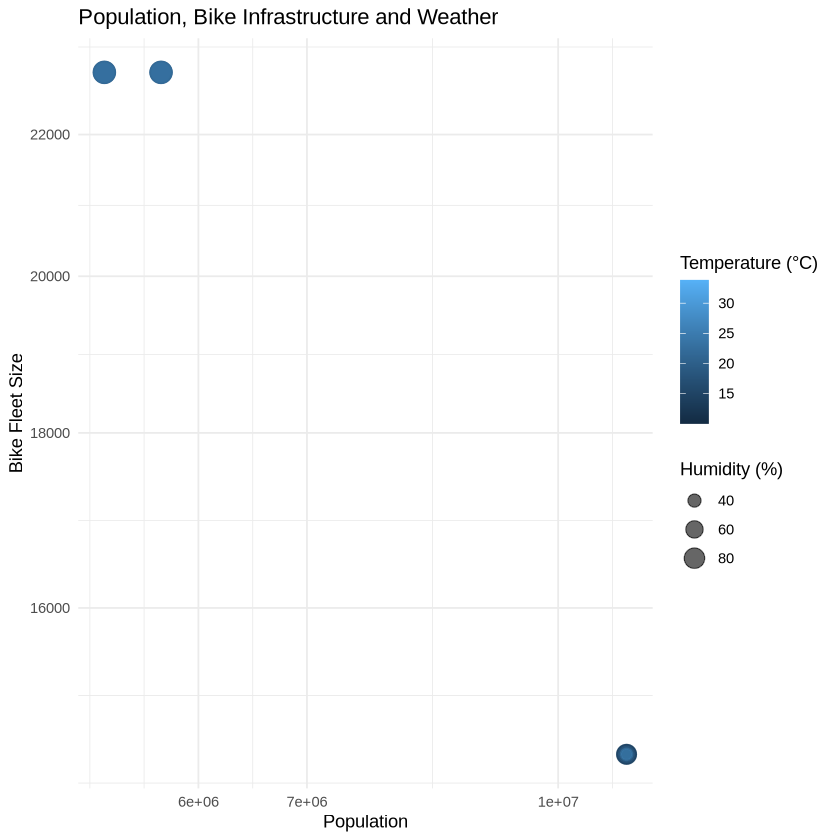

In [88]:
ggplot(
  bike_population_weather,
  aes(
    x = POPULATION,
    y = BICYCLES,
    colour = TEMP,
    size = HUMIDITY
  )
) +
  geom_point(alpha = 0.6) +
  scale_x_log10() +
  scale_y_log10() +
  labs(
    title = "Population, Bike Infrastructure and Weather",
    x = "Population",
    y = "Bike Fleet Size",
    colour = "Temperature (°C)",
    size = "Humidity (%)"
  ) +
  theme_minimal()

Bike infrastructure relative to population and weather.

A cleaner three-dataset approach is to calculate bicycles per 1,000 people first.

`geom_smooth()` using formula = 'y ~ x'


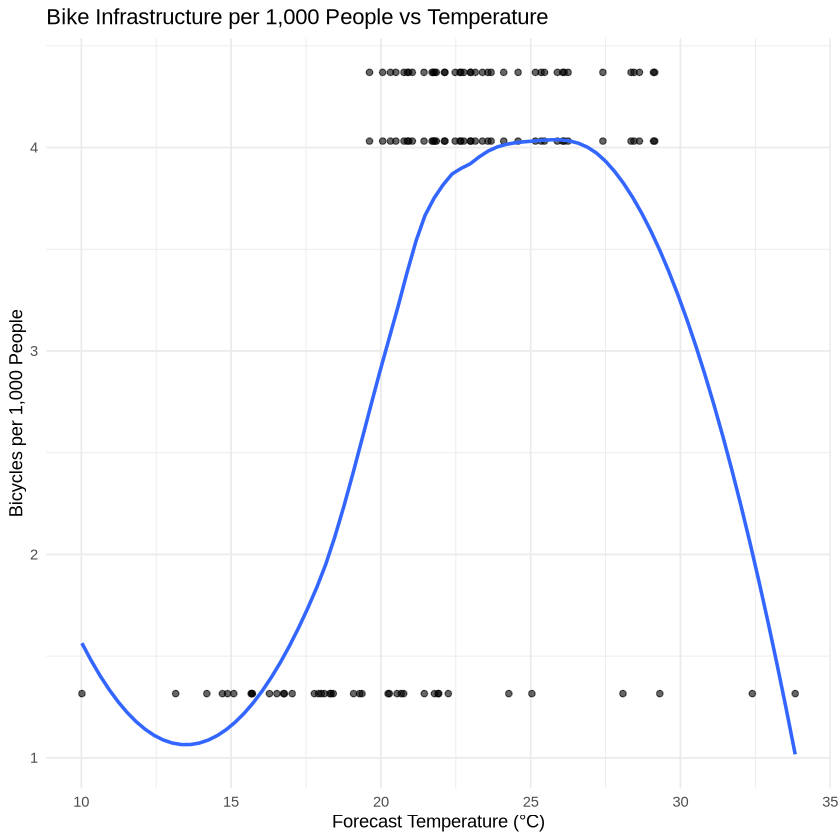

In [89]:
bike_population_weather <- bike_population_weather %>%
  mutate(
    bicycles_per_1000 =
      BICYCLES * 1000 / POPULATION
  )

  ggplot(
  bike_population_weather,
  aes(
    x = TEMP,
    y = bicycles_per_1000
  )
) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "loess", se = FALSE) +
  labs(
    title = "Bike Infrastructure per 1,000 People vs Temperature",
    x = "Forecast Temperature (°C)",
    y = "Bicycles per 1,000 People"
  ) +
  theme_minimal()

This is arguably easier to interpret than raw fleet size because it accounts for city population.

One visualization that ties together the three major city-level datasets.

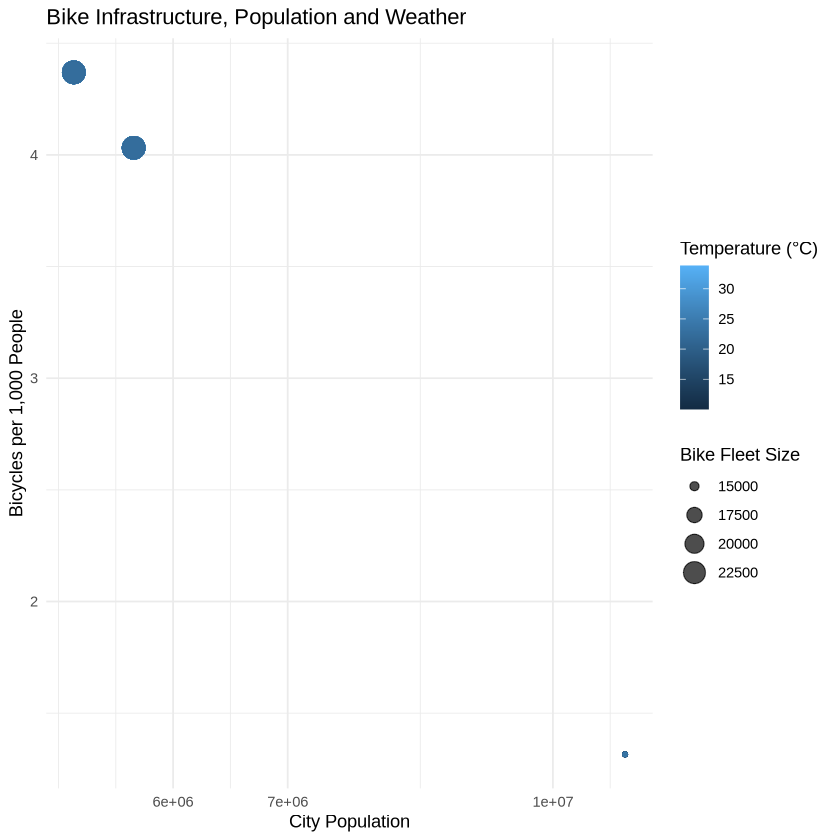

In [90]:
ggplot(
  bike_population_weather,
  aes(
    x = POPULATION,
    y = bicycles_per_1000,
    colour = TEMP,
    size = BICYCLES
  )
) +
  geom_point(alpha = 0.7) +
  scale_x_log10() +
  labs(
    title = "Bike Infrastructure, Population and Weather",
    x = "City Population",
    y = "Bicycles per 1,000 People",
    colour = "Temperature (°C)",
    size = "Bike Fleet Size"
  ) +
  theme_minimal()

Here:

- Population -> processed_worldcities
- Bicycles per 1,000 people -> calculated using processed_bike_sharing_systems + processed_worldcities
- Temperature -> processed_cities_weather_forecast
- Fleet size -> processed_bike_sharing_systems